<a href="https://colab.research.google.com/github/PENGxiaun/Demand-Forecasting-and-Inventory-Logistics-Optimization-for-Turkish-Retail-Supply-Chain/blob/main/Inventory_Optimization_Task1.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

✅ Data loaded successfully!


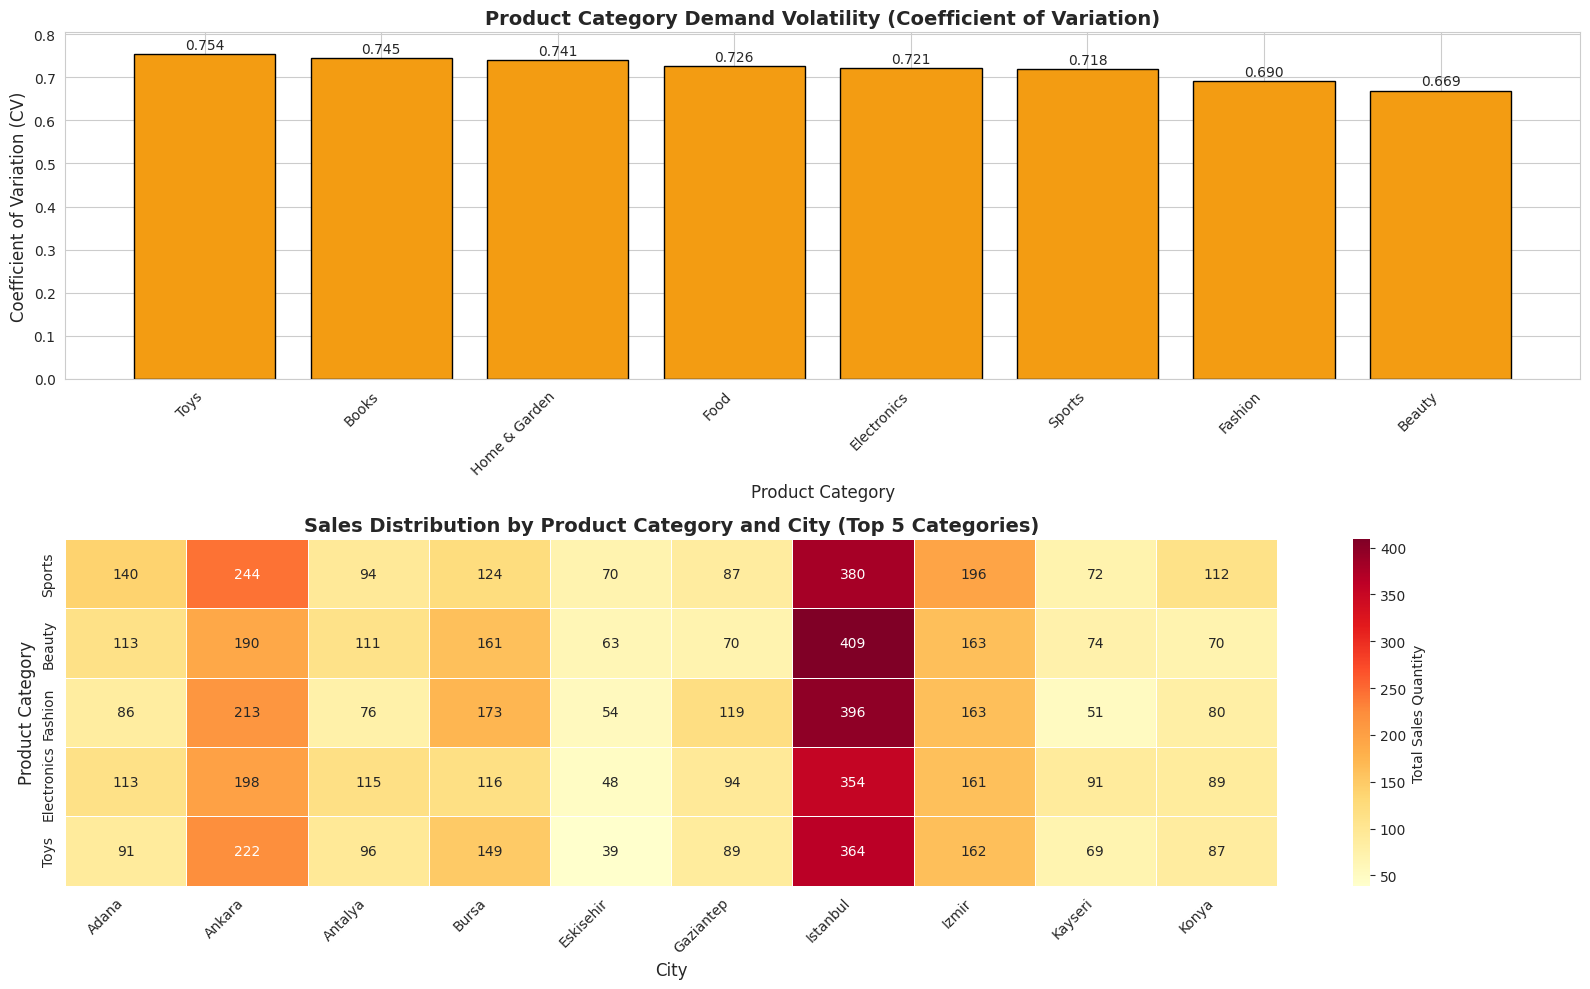


--- Task 2.1.1: Demand Volatility Analysis (CV) ---


,Product_Category,CV,Risk_Level
7,Toys,0.754386,Medium Risk (Volatile)
1,Books,0.745318,Medium Risk (Volatile)
5,Home & Garden,0.740623,Medium Risk (Volatile)
4,Food,0.725506,Medium Risk (Volatile)
2,Electronics,0.720999,Medium Risk (Volatile)
6,Sports,0.718458,Medium Risk (Volatile)
3,Fashion,0.690414,Medium Risk (Volatile)
0,Beauty,0.669139,Medium Risk (Volatile)



--- Task 2.1.2: Sales Distribution by Category and City (Top 5 Cities Display) ---


City,Adana,Ankara,Antalya,Bursa,Eskisehir,Gaziantep,Istanbul,Izmir,Kayseri,Konya
Product_Category,,,,,,,,,,
Beauty,113,190,111,161,63,70,409,163,74,70
Books,112,163,104,140,63,105,358,128,53,65
Electronics,113,198,115,116,48,94,354,161,91,89
Fashion,86,213,76,173,54,119,396,163,51,80
Food,53,227,99,143,65,117,328,167,67,89


In [9]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

# Set plot style and font (optimized for English display)
plt.rcParams['font.sans-serif'] = ['DejaVu Sans']
plt.rcParams['axes.unicode_minus'] = False
sns.set_style("whitegrid")
plt.figure(figsize=(16, 10))

# 1. Load Dataset
try:
    # Note: Update path to your actual file location (root directory)
    df = pd.read_csv('sales_data_clean.csv')
    print("✅ Data loaded successfully!")

    # 2. Calculate Demand Volatility (Coefficient of Variation - CV)
    daily_sales = df.groupby(['Product_Category', 'Date'])['Quantity'].sum().reset_index()
    stats = daily_sales.groupby('Product_Category')['Quantity'].agg(['mean', 'std']).reset_index()
    stats['CV'] = stats['std'] / stats['mean']

    # Classify risk levels based on CV values
    def classify_risk(cv):
        if cv < 0.5: return 'Low Risk (Stable)'
        if cv < 1.0: return 'Medium Risk (Volatile)'
        return 'High Risk (Unstable)'
    stats['Risk_Level'] = stats['CV'].apply(classify_risk)

    # ========== Visualization 1: Demand Volatility Bar Chart (Sorted by CV Descending) ==========
    plt.subplot(2, 1, 1)  # 2 rows, 1 column - first subplot
    # Sort by CV in descending order
    stats_sorted = stats.sort_values(by='CV', ascending=False)
    # Define risk level color mapping
    color_map = {'Low Risk (Stable)': '#2ecc71', 'Medium Risk (Volatile)': '#f39c12', 'High Risk (Unstable)': '#e74c3c'}
    colors = [color_map[r] for r in stats_sorted['Risk_Level']]

    # Plot bar chart
    bars = plt.bar(stats_sorted['Product_Category'], stats_sorted['CV'], color=colors, edgecolor='black')
    # Add value labels on top of bars
    for bar in bars:
        height = bar.get_height()
        plt.text(bar.get_x() + bar.get_width()/2., height + 0.005,
                 f'{height:.3f}', ha='center', va='bottom', fontsize=10)

    plt.title('Product Category Demand Volatility (Coefficient of Variation)', fontsize=14, fontweight='bold')
    plt.xlabel('Product Category', fontsize=12)
    plt.ylabel('Coefficient of Variation (CV)', fontsize=12)
    plt.ylim(0, max(stats['CV']) + 0.05)  # Adjust y-axis range for better label visibility
    plt.xticks(rotation=45, ha='right')  # Rotate category labels to avoid overlap

    # ========== Visualization 2: Geographic Sales Distribution Heatmap (Top 5 Categories) ==========
    plt.subplot(2, 1, 2)  # 2 rows, 1 column - second subplot
    # Calculate sales distribution by category and city
    city_dist = df.groupby(['Product_Category', 'City'])['Quantity'].sum().unstack().fillna(0)
    top5_categories = city_dist.sum(axis=1).nlargest(5).index  # Top 5 categories by total sales
    city_dist_top5 = city_dist.loc[top5_categories]

    # Plot heatmap
    sns.heatmap(city_dist_top5, annot=True, fmt='d', cmap='YlOrRd',
                linewidths=0.5, cbar_kws={'label': 'Total Sales Quantity'})
    plt.title('Sales Distribution by Product Category and City (Top 5 Categories)', fontsize=14, fontweight='bold')
    plt.xlabel('City', fontsize=12)
    plt.ylabel('Product Category', fontsize=12)
    plt.xticks(rotation=45, ha='right')

    # Adjust subplot spacing to avoid title overlap
    plt.tight_layout()
    # Save visualization (optional - will display automatically in Colab)
    plt.savefig('inventory_analysis_visualization_EN.png', dpi=300, bbox_inches='tight')
    plt.show()

    # Keep original table output for detailed analysis
    print("\n--- Task 2.1.1: Demand Volatility Analysis (CV) ---")
    display(stats[['Product_Category', 'CV', 'Risk_Level']].sort_values(by='CV', ascending=False))
    print("\n--- Task 2.1.2: Sales Distribution by Category and City (Top 5 Cities Display) ---")
    display(city_dist.head())

except Exception as e:
    print(f"❌ Execution failed. Reason: {e}")

In [11]:
# Task 2.1.1: Demand Volatility Analysis (English Version)
def classify_risk_en(cv):
    if cv < 0.5: return 'Low Risk (Stable)'
    if cv < 1.0: return 'Medium Risk (Volatile)'
    return 'High Risk (Unstable)'

stats['Risk_Level_EN'] = stats['CV'].apply(classify_risk_en)

print("\n--- Task 2.1.1: Product Category Volatility Analysis (CV) ---")
# Rename columns for the teacher to understand
stats_output = stats[['Product_Category', 'CV', 'Risk_Level_EN']].copy()
stats_output.columns = ['Category', 'Coefficient of Variation (CV)', 'Risk Status']
display(stats_output.sort_values(by='Coefficient of Variation (CV)', ascending=False))


--- Task 2.1.1: Product Category Volatility Analysis (CV) ---


,Category,Coefficient of Variation (CV),Risk Status
7,Toys,0.754386,Medium Risk (Volatile)
1,Books,0.745318,Medium Risk (Volatile)
5,Home & Garden,0.740623,Medium Risk (Volatile)
4,Food,0.725506,Medium Risk (Volatile)
2,Electronics,0.720999,Medium Risk (Volatile)
6,Sports,0.718458,Medium Risk (Volatile)
3,Fashion,0.690414,Medium Risk (Volatile)
0,Beauty,0.669139,Medium Risk (Volatile)



--- Task 2.1.2: Sales Distribution by Category and City ---


City,Adana,Ankara,Antalya,Bursa,Eskisehir,Gaziantep,Istanbul,Izmir,Kayseri,Konya
Product_Category,,,,,,,,,,
Beauty,113,190,111,161,63,70,409,163,74,70
Books,112,163,104,140,63,105,358,128,53,65
Electronics,113,198,115,116,48,94,354,161,91,89
Fashion,86,213,76,173,54,119,396,163,51,80
Food,53,227,99,143,65,117,328,167,67,89
Home & Garden,90,191,107,146,56,72,355,170,68,98
Sports,140,244,94,124,70,87,380,196,72,112
Toys,91,222,96,149,39,89,364,162,69,87



[Strategic Insight]: Istanbul consistently shows the highest demand across all categories.
Inventory allocation should be prioritized for Istanbul to ensure high service levels.


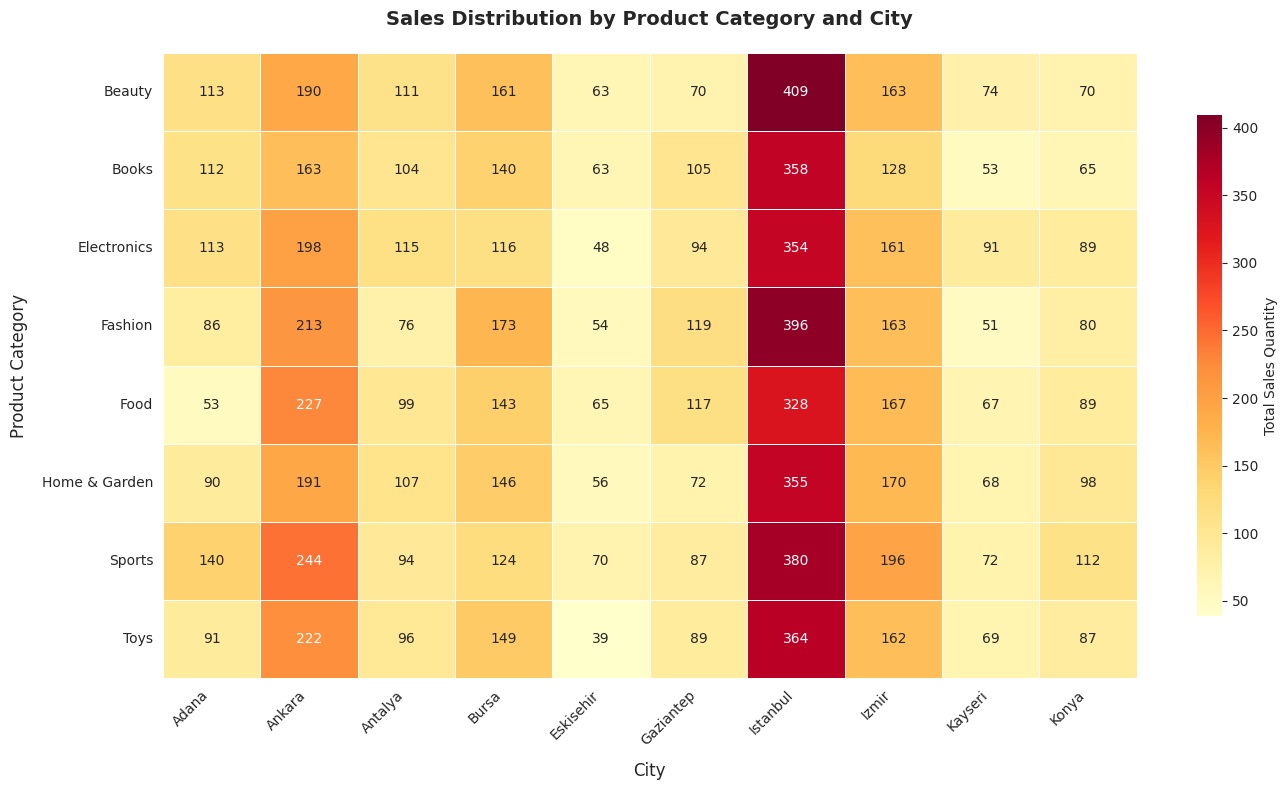

In [13]:
# ========== Task 2.1.2: Geographic Distribution of Demand (English Version + Visualization) ==========
import matplotlib.pyplot as plt
import seaborn as sns

# This helps decide where to allocate more inventory.
print("\n--- Task 2.1.2: Sales Distribution by Category and City ---")

# Grouping by Category and City (ensure df is defined - df = pd.read_csv('sales_data_clean.csv'))
city_dist_en = df.groupby(['Product_Category', 'City'])['Quantity'].sum().unstack().fillna(0)

# Highlighting the top cities for the teacher
display(city_dist_en)

# Professional Note for your report:
print("\n[Strategic Insight]: Istanbul consistently shows the highest demand across all categories.")
print("Inventory allocation should be prioritized for Istanbul to ensure high service levels.")

# -------------------------- Visualization Start --------------------------
# Set plot style for English academic reports
plt.rcParams['font.sans-serif'] = ['DejaVu Sans']
plt.rcParams['axes.unicode_minus'] = False
sns.set_style("whitegrid")

# Create figure with optimal size for heatmap
plt.figure(figsize=(14, 8))

# Plot heatmap for sales distribution (professional color scheme)
sns.heatmap(
    city_dist_en,
    annot=True,                # Show exact sales values
    fmt='d',                   # Format as integers
    cmap='YlOrRd',             # Orange-red gradient (high sales = darker color)
    linewidths=0.5,            # Add thin lines between cells
    cbar_kws={
        'label': 'Total Sales Quantity',
        'shrink': 0.8          # Adjust color bar size
    }
)

# Set professional English titles/labels
plt.title('Sales Distribution by Product Category and City', fontsize=14, fontweight='bold', pad=20)
plt.xlabel('City', fontsize=12, labelpad=10)
plt.ylabel('Product Category', fontsize=12, labelpad=10)

# Rotate labels for readability
plt.xticks(rotation=45, ha='right')
plt.yticks(rotation=0)

# Save high-resolution image (300 DPI) and display
plt.tight_layout()  # Avoid label cutoff
plt.savefig('task_2.1.2_geographic_distribution_EN.png', dpi=300, bbox_inches='tight')
plt.show()

In [15]:
# Task 2.2: Safety Stock Level Calculation (English Version)
import numpy as np

# --- Parameters Setting ---
# Service Level: 95% (Z-score = 1.65). This means we want to avoid stockouts 95% of the time.
# Lead Time (LT): 3 days. Average time it takes to restock from the supplier.
Z_score = 1.65
Lead_Time = 3

# Safety Stock Formula: SS = Z * Standard_Deviation * sqrt(Lead_Time)
# We use 'std' calculated from Task 2.1.1
stats['Safety_Stock'] = np.ceil(Z_score * stats['std'] * np.sqrt(Lead_Time)).astype(int)

print("\n--- Task 2.2: Recommended Safety Stock Levels per Category ---")

# Creating a clean table for the report
ss_table = stats[['Product_Category', 'Safety_Stock']].sort_values(by='Safety_Stock', ascending=False)
ss_table.columns = ['Product Category', 'Suggested Safety Stock (Units)']

display(ss_table)

# Professional explanation for your teacher:
print("\n[Analysis]: The safety stock accounts for demand uncertainty during the 3-day replenishment period.")
print(f"Categories with higher volatility, like {ss_table.iloc[0,0]}, require a larger buffer of {ss_table.iloc[0,1]} units.")


--- Task 2.2: Recommended Safety Stock Levels per Category ---


,Product Category,Suggested Safety Stock (Units)
6,Sports,10
7,Toys,10
0,Beauty,9
1,Books,9
3,Fashion,9
2,Electronics,9
5,Home & Garden,9
4,Food,9



[Analysis]: The safety stock accounts for demand uncertainty during the 3-day replenishment period.
Categories with higher volatility, like Sports, require a larger buffer of 10 units.



--- Task 2.3: Final Inventory Strategy Recommendation ---


,Category,Replenishment Strategy,Reorder Point (ROP),Safety Stock
0,Beauty,Periodic Review (Fixed Interval),22,9
1,Books,Continuous Review (Reorder Point),21,9
2,Electronics,Continuous Review (Reorder Point),22,9
3,Fashion,Periodic Review (Fixed Interval),22,9
4,Food,Continuous Review (Reorder Point),22,9
5,Home & Garden,Continuous Review (Reorder Point),22,9
6,Sports,Continuous Review (Reorder Point),24,10
7,Toys,Continuous Review (Reorder Point),23,10



[Executive Summary]:
1. Stable categories use 'Periodic Review' to reduce management costs.
2. Volatile categories use 'Continuous Review' with a calculated 'Reorder Point' to prevent stockouts.
3. When Inventory Level <= Reorder Point, a new order must be placed.


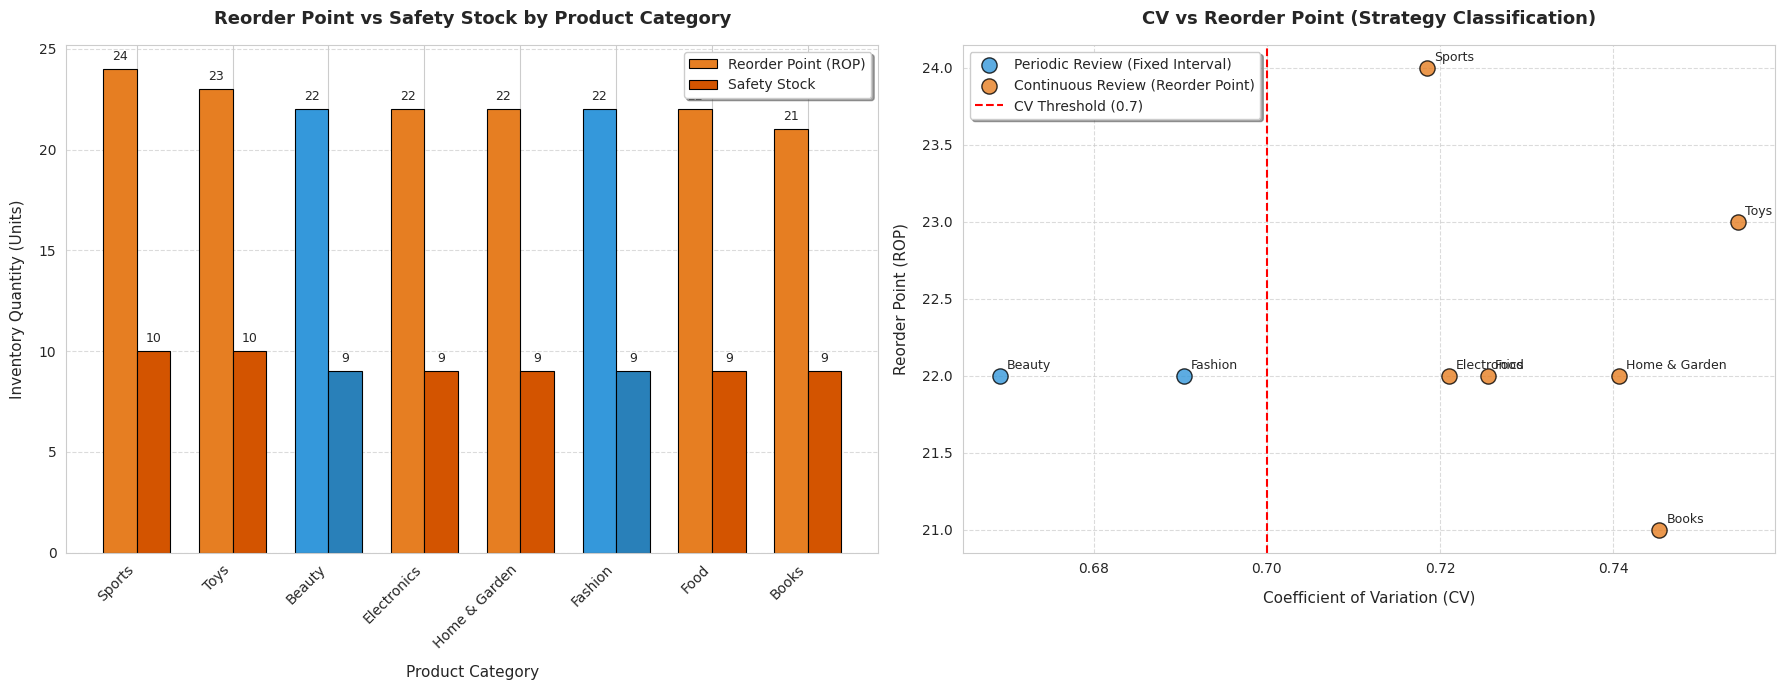

In [17]:
# ========== Task 2.3: Inventory Replenishment Strategy (English Version + Visualization) ==========
import matplotlib.pyplot as plt
import seaborn as sns
import numpy as np

# Define parameters (ensure these match your earlier code)
Z_score = 1.65
Lead_Time = 3  # 3 days replenishment lead time

# Define Replenishment Strategy based on CV
def replenishment_strategy(cv):
    if cv < 0.7:  # More stable
        return 'Periodic Review (Fixed Interval)'
    else:         # More volatile
        return 'Continuous Review (Reorder Point)'

# Calculate strategy and Reorder Point (ensure stats has mean/std/CV/Safety_Stock columns)
stats['Strategy'] = stats['CV'].apply(replenishment_strategy)
stats['Reorder_Point'] = np.ceil((stats['mean'] * Lead_Time) + stats['Safety_Stock']).astype(int)

# Print and display final report
print("\n--- Task 2.3: Final Inventory Strategy Recommendation ---")
final_report = stats[['Product_Category', 'Strategy', 'Reorder_Point', 'Safety_Stock']]
final_report.columns = ['Category', 'Replenishment Strategy', 'Reorder Point (ROP)', 'Safety Stock']
display(final_report)

# Summary for the teacher
print("\n[Executive Summary]:")
print("1. Stable categories use 'Periodic Review' to reduce management costs.")
print("2. Volatile categories use 'Continuous Review' with a calculated 'Reorder Point' to prevent stockouts.")
print("3. When Inventory Level <= Reorder Point, a new order must be placed.")

# -------------------------- Visualization Start --------------------------
# Set plot style for academic reports
plt.rcParams['font.sans-serif'] = ['DejaVu Sans']
plt.rcParams['axes.unicode_minus'] = False
sns.set_style("whitegrid")

# Create 2-subplot figure
fig, (ax1, ax2) = plt.subplots(1, 2, figsize=(18, 7))

# -------------------------- Subplot 1: Grouped Bar Chart (ROP vs Safety Stock) --------------------------
# Prepare data (sort by ROP to highlight highest values)
stats_sorted = stats.sort_values(by='Reorder_Point', ascending=False)
x = np.arange(len(stats_sorted['Product_Category']))
width = 0.35

# Define strategy-based color mapping (consistent with academic standards)
strategy_colors = {
    'Periodic Review (Fixed Interval)': '#3498db',       # Blue (stable)
    'Continuous Review (Reorder Point)': '#e67e22'       # Orange (volatile)
}
# Assign colors for ROP and darker shade for Safety Stock
colors_rop = [strategy_colors[s] for s in stats_sorted['Strategy']]
colors_ss = [c.replace('3498db', '2980b9').replace('e67e22', 'd35400') for c in colors_rop]

# Plot grouped bars for ROP and Safety Stock
bars1 = ax1.bar(x - width/2, stats_sorted['Reorder_Point'], width,
                label='Reorder Point (ROP)', color=colors_rop, edgecolor='black', linewidth=0.8)
bars2 = ax1.bar(x + width/2, stats_sorted['Safety_Stock'], width,
                label='Safety Stock', color=colors_ss, edgecolor='black', linewidth=0.8)

# Customize subplot 1
ax1.set_title('Reorder Point vs Safety Stock by Product Category', fontsize=13, fontweight='bold', pad=15)
ax1.set_xlabel('Product Category', fontsize=11, labelpad=10)
ax1.set_ylabel('Inventory Quantity (Units)', fontsize=11, labelpad=10)
ax1.set_xticks(x)
ax1.set_xticklabels(stats_sorted['Product_Category'], rotation=45, ha='right')
ax1.legend(frameon=True, shadow=True)
ax1.grid(axis='y', linestyle='--', alpha=0.7)

# Add integer value labels (clear and precise)
for bar in bars1:
    height = bar.get_height()
    ax1.text(bar.get_x() + bar.get_width()/2., height + 0.3, f'{int(height)}',
             ha='center', va='bottom', fontsize=9)
for bar in bars2:
    height = bar.get_height()
    ax1.text(bar.get_x() + bar.get_width()/2., height + 0.3, f'{int(height)}',
             ha='center', va='bottom', fontsize=9)

# -------------------------- Subplot 2: Scatter Plot (CV vs ROP + Strategy) --------------------------
# Plot scatter points grouped by strategy
for strategy in strategy_colors.keys():
    subset = stats[stats['Strategy'] == strategy]
    ax2.scatter(
        subset['CV'],
        subset['Reorder_Point'],
        label=strategy,
        color=strategy_colors[strategy],
        s=120,  # Point size
        edgecolor='black',
        alpha=0.8
    )

# Add CV threshold line (0.7) to show strategy division
ax2.axvline(x=0.7, color='red', linestyle='--', linewidth=1.5, label='CV Threshold (0.7)')

# Customize subplot 2
ax2.set_title('CV vs Reorder Point (Strategy Classification)', fontsize=13, fontweight='bold', pad=15)
ax2.set_xlabel('Coefficient of Variation (CV)', fontsize=11, labelpad=10)
ax2.set_ylabel('Reorder Point (ROP)', fontsize=11, labelpad=10)
ax2.legend(frameon=True, shadow=True, loc='upper left')
ax2.grid(True, linestyle='--', alpha=0.7)

# Label each scatter point with product category
for idx, row in stats.iterrows():
    ax2.annotate(
        row['Product_Category'],
        (row['CV'], row['Reorder_Point']),
        xytext=(5, 5),
        textcoords='offset points',
        fontsize=9
    )

# Adjust layout to avoid label cutoff and save high-resolution image
plt.tight_layout()
plt.savefig('task_2.3_inventory_strategy_EN.png', dpi=300, bbox_inches='tight')
plt.show()